In [1]:
# imports

import cv2
import numpy as np
from imgbeddings import imgbeddings
from PIL import Image
from IPython.display import display
import IPython.display as ipd




/Users/student/PycharmProjects/FaceReco/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
#initialise the AI tools

ibed=imgbeddings()
haarcascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')


/Users/student/PycharmProjects/FaceReco/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:671: FutureWarning: 'cached_download' is the legacy way to download files from the HF hub, please consider upgrading to 'hf_hub_download'
  warnings.warn(
/Users/student/PycharmProjects/FaceReco/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/student/PycharmProjects/FaceReco/.venv/lib/python3.11/site-packages/transformers/models/clip/processing_clip.py:144: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


In [3]:
#ask user for input of group photo and photo of user they want to see in the group

group_path=input("enter path for the group image").strip()
person_path=input("enter path for the person image").strip()

#gets the embedding for the specific person we are looking for
person_img=cv2.imread(person_path,cv2.IMREAD_GRAYSCALE)
person_faces=haarcascade.detectMultiScale(person_img,scaleFactor=1.1,minNeighbors=5,minSize=(30,30))


In [4]:
#check to see if face exsists then displaying the first face found if there is one
if len(person_faces)==0:
    print("no faces detected")
else:
    x,y,w,h=person_faces[0]
    person_crop=person_img[y:y+h,x:x+w]
    target_embedding=ibed.to_embeddings(Image.fromarray(person_crop))[0]

    group_img_grey=cv2.imread(group_path,cv2.IMREAD_GRAYSCALE)
    group_img_color=cv2.imread(group_path)

    group_faces=haarcascade.detectMultiScale(group_img_grey,scaleFactor=1.1,minNeighbors=5,minSize=(30,30))
    print(f"{len(group_faces)} faces detected")

    best_match_index=-1
    shortest_dis=float('inf')



5 faces detected


In [6]:
#compares every face in the group to the target person

if 'group_faces' in locals():
    for i,(gx,gy,gw,gh) in enumerate(group_faces):
        group_crop = group_img_grey[gy:gy+gh, gx:gx+gw]
        group_embedding=ibed.to_embeddings(Image.fromarray(group_crop))[0]

        distance=np.linalg.norm(target_embedding-group_embedding)
        if distance<shortest_dis:
            best_match_index=i
            shortest_dis=distance
else:
    print({"unable to compare"})



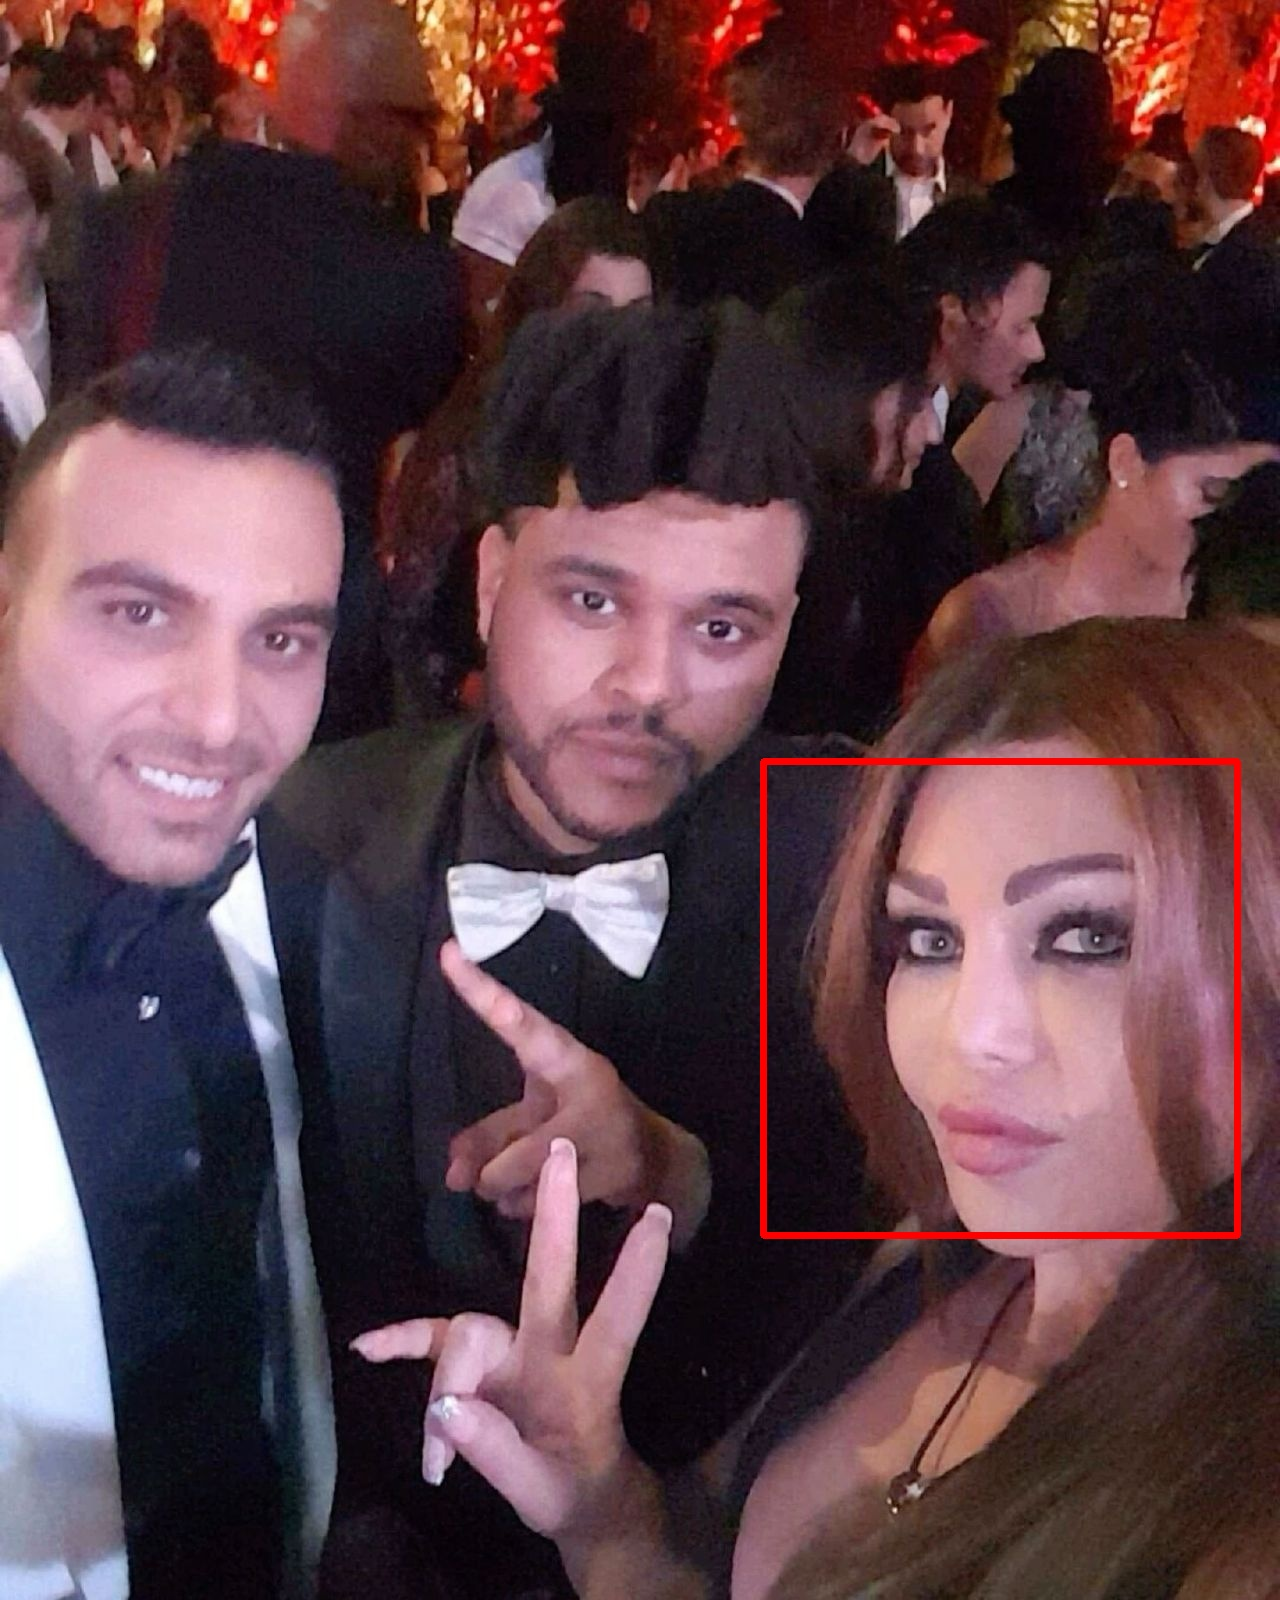

In [7]:
#displays final resualt
if best_match_index!=-1:
    mx,my,mw,mh=group_faces[best_match_index]
    cv2.rectangle(group_img_color,(mx,my),(mx+mw,my+mh),(0,0,255),5)

    result_filename="app_result_temp.jpg"
    cv2.imwrite(result_filename,group_img_color)
    display(ipd.Image(filename=result_filename))
else:
    print("no faces detected")